# Reasoning and Acting AI Agents with LangGraph

## Agente ReAct Multi-Herramienta con Trazabilidad Completa de Razonamiento

**Framework:** LangChain + LangGraph (StateGraph + Reducers)  
**Patrón:** ReAct (Reasoning + Acting) — Thought → Action → Observation → ... → Answer  
**Lenguaje:** 100% Español  
**Python:** 3.13 (env-llm-ia) ✅  

---

### ¿Qué es ReAct?

ReAct es un patrón donde el agente alterna entre:
1. **Reasoning (Pensamiento):** Genera un pensamiento lógico
2. **Acting (Acción):** Ejecuta una herramienta
3. **Observation (Observación):** Procesa el resultado
4. **Repeat:** Hasta llegar a la respuesta final

### ¿Por qué LangGraph + Reducers?

- **State explícito:** Razonamiento como datos estructurados, no texto parseado
- **Reducers:** `Annotated[list, operator.add]` acumula pasos automáticamente
- **Benchmarking trivial:** `len(state["reasoning_steps"])` = número de pasos
- **Auditoría completa:** Todo el trace está disponible en el state final





Ver **REPORTE_TECNICO_LANGGRAPH.md** para explicación profunda.

---

## Celda 1: Verificación de Entorno

Verificamos que Python 3.14 está disponible y que Ollama está conectado.

In [50]:
import sys
import subprocess
import requests
import configparser
import os


# Verificar Python
print(f"[INFO] Python version: {sys.version}")
print(f"[INFO] Python executable: {sys.executable}")

if sys.version_info >= (3, 13):
    print("[OK] Python 3.13+ ✓")
else:
    print(f"[WARN] Python {sys.version_info.major}.{sys.version_info.minor} detectado")
    print("[WARN] Se recomienda Python 3.13 (env-llm-ia) para mejor compatibilidad")

"""

# Verificar dependencias clave
deps_requeridas = {
    "langchain": "LangChain (orquestación)",
    "langgraph": "LangGraph (StateGraph + Reducers)",
    "pandas": "Pandas (análisis de datos)",
    "matplotlib": "Matplotlib (visualización)",
}

print("\n[INFO] Verificando dependencias:")
missing = []
for pkg, desc in deps_requeridas.items():
    try:
        __import__(pkg)
        print(f"  ✓ {pkg:20} - {desc}")
    except ImportError:
        print(f"  ✗ {pkg:20} - {desc}")
        missing.append(pkg)

if missing:
    print(f"\n[ERROR] Dependencias faltantes: {', '.join(missing)}")
    print("[INFO] Instalar con: pip install -r requirements.txt")
    sys.exit(1)
else:
    print("\n[OK] Todas las dependencias disponibles ✓")

"""

[INFO] Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
[INFO] Python executable: c:\workspace-vc\env-llm-ia\Scripts\python.exe
[OK] Python 3.13+ ✓


'\n\n# Verificar dependencias clave\ndeps_requeridas = {\n    "langchain": "LangChain (orquestación)",\n    "langgraph": "LangGraph (StateGraph + Reducers)",\n    "pandas": "Pandas (análisis de datos)",\n    "matplotlib": "Matplotlib (visualización)",\n}\n\nprint("\n[INFO] Verificando dependencias:")\nmissing = []\nfor pkg, desc in deps_requeridas.items():\n    try:\n        __import__(pkg)\n        print(f"  ✓ {pkg:20} - {desc}")\n    except ImportError:\n        print(f"  ✗ {pkg:20} - {desc}")\n        missing.append(pkg)\n\nif missing:\n    print(f"\n[ERROR] Dependencias faltantes: {\', \'.join(missing)}")\n    print("[INFO] Instalar con: pip install -r requirements.txt")\n    sys.exit(1)\nelse:\n    print("\n[OK] Todas las dependencias disponibles ✓")\n\n'

In [51]:


# Cargar config.ini
config = configparser.ConfigParser()
config.read('config.ini', encoding='utf-8')

ollama_base_url = config.get('ollama', 'base_url', fallback='http://localhost:11434')
ollama_model = config.get('ollama', 'model_name', fallback='qwen2.5:7b')

print(f"[INFO] Ollama URL: {ollama_base_url}")
print(f"[INFO] Modelo: {ollama_model}")

# Verificar conectividad
try:
    resp = requests.get(f"{ollama_base_url}/api/tags", timeout=5)
    if resp.status_code == 200:
        models = resp.json().get('models', [])
        print(f"[OK] Ollama conectado. {len(models)} modelos disponibles.")
        
        # Verificar modelo específico
        model_names = [m.get('name') for m in models]
        if ollama_model in model_names:
            print(f"[OK] Modelo '{ollama_model}' disponible ✓")
        else:
            print(f"[WARN] Modelo '{ollama_model}' NO encontrado")
            print(f"[INFO] Modelos disponibles: {', '.join(model_names[:3])}...")
            print(f"[INFO] Descargar con: ollama pull {ollama_model}")
    else:
        print(f"[ERROR] Ollama respondió con status {resp.status_code}")
except requests.exceptions.ConnectionError:
    print(f"[ERROR] No se pudo conectar a Ollama en {ollama_base_url}")
    print(f"[INFO] Ejecuta en otra terminal: ollama serve")

[INFO] Ollama URL: http://localhost:11434
[INFO] Modelo: mistral:7b
[OK] Ollama conectado. 11 modelos disponibles.
[OK] Modelo 'mistral:7b' disponible ✓


## Celda 3: Cargar Configuración

Cargamos parámetros desde `config.ini` de forma centralizada.

In [52]:
# Parámetros Ollama
ollama_temperature = config.getfloat('ollama', 'temperature', fallback=0.3)
ollama_max_tokens = config.getint('ollama', 'max_tokens', fallback=2000)
ollama_num_ctx = config.getint('ollama', 'num_ctx', fallback=8192)

# Parámetros del agente ReAct
verbose = config.getboolean('agente', 'verbose', fallback=True)
return_intermediate_steps = config.getboolean('agente', 'return_intermediate_steps', fallback=True)
max_iterations = config.getint('agente', 'max_iterations', fallback=10)

# Parámetros de benchmark
benchmark_enabled = config.getboolean('benchmark', 'enabled', fallback=True)
variant_label = config.get('benchmark', 'variant_label', fallback='').strip()
if not variant_label:
    variant_label = f"{ollama_model}_t{ollama_temperature}_react"

print(f"\n[CONFIG LOADED]")
print(f"  Ollama: {ollama_base_url}")
print(f"  Modelo: {ollama_model}")
print(f"  Temperatura: {ollama_temperature}")
print(f"  Max tokens: {ollama_max_tokens}")
print(f"  Max iterations ReAct: {max_iterations}")
print(f"  Benchmark enabled: {benchmark_enabled}")
print(f"  Variant label: {variant_label}")


[CONFIG LOADED]
  Ollama: http://localhost:11434
  Modelo: mistral:7b
  Temperatura: 0.3
  Max tokens: 2000
  Max iterations ReAct: 10
  Benchmark enabled: True
  Variant label: mistral:7b_t0.3_react


In [53]:
# ═══════════════════════════════════════════════════════════════════════════
# Crear LLM con Ollama
# ═══════════════════════════════════════════════════════════════════════════

from langchain_ollama import ChatOllama

llm = ChatOllama(
    base_url=ollama_base_url,
    model=ollama_model,
    temperature=ollama_temperature,
    num_ctx=ollama_num_ctx,
)

print(f"[OK] LLM creado: {ollama_model}")


[OK] LLM creado: mistral:7b


## Celda 4: Definir Herramientas (Tools)

Creamos las 4 herramientas que el agente ReAct puede usar:
1. Calculadora (aritmética básica)
2. Wikipedia (búsqueda de conocimiento)
3. Fecha/Hora (información temporal)
4. Conversor de Unidades (temperatura, distancia, peso)

In [54]:
from langchain_core.tools import tool
import math
from datetime import datetime
import wikipedia

# ═══════════════════════════════════════════════════════════════════════════
# Tool 1: Calculadora (usando decorador @tool)
# ═══════════════════════════════════════════════════════════════════════════

@tool
def calculator(expression: str) -> str:
    """
    Calcula expresiones aritméticas simples.
    Soporta: +, -, *, /, **, sqrt, sin, cos, tan, log, etc.
    """
    try:
        safe_dict = {
            '__builtins__': {},
            'sqrt': math.sqrt,
            'sin': math.sin,
            'cos': math.cos,
            'tan': math.tan,
            'log': math.log,
            'pi': math.pi,
            'e': math.e,
        }
        result = eval(expression, safe_dict)
        return str(result)
    except Exception as e:
        return f"Error: {e}"

# ═══════════════════════════════════════════════════════════════════════════
# Tool 2: Wikipedia (usando decorador @tool)
# ═══════════════════════════════════════════════════════════════════════════

@tool
def wikipedia_search(query: str) -> str:
    """
    Busca información en Wikipedia.
    Ejemplo: 'Paracetamol', 'París'
    """
    try:
        wikipedia.set_lang('es')
        result = wikipedia.summary(query, sentences=3, auto_suggest=True)
        return result
    except wikipedia.exceptions.DisambiguationError as e:
        return f"Ambigüedad: {e.options[:3]}"
    except wikipedia.exceptions.PageError:
        return f"No se encontró: {query}"
    except Exception as e:
        return f"Error: {e}"

# ═══════════════════════════════════════════════════════════════════════════
# Tool 3: Fecha/Hora (usando decorador @tool)
# ═══════════════════════════════════════════════════════════════════════════

@tool
def get_datetime(query: str = "") -> str:
    """
    Devuelve la fecha y hora actual del sistema
    """
    now = datetime.now()
    return f"Fecha: {now.strftime('%Y-%m-%d')}, Hora: {now.strftime('%H:%M:%S')}"

# ═══════════════════════════════════════════════════════════════════════════
# Tool 4: Conversor de Unidades (usando decorador @tool)
# ═══════════════════════════════════════════════════════════════════════════

@tool
def unit_converter(input_str: str) -> str:
    """
    Convierte unidades: temperatura, distancia, peso.
    Formato: '100 kg to lb' o '32 F to C'
    Ejemplos:
    - '32 F to C' → '32°F = 0.00°C'
    - '100 kg to lb' → '100 kg = 220.46 lb'
    - '5 km to m' → '5 km = 5000 m'
    """
    try:
        parts = input_str.split()
        if len(parts) < 3:
            return "Formato: '100 kg to lb' o '32 F to C'"
        
        value = float(parts[0])
        from_unit = parts[1].lower()
        to_unit = parts[-1].lower()
        
        # Conversiones de temperatura
        if from_unit in ['f', 'fahrenheit'] and to_unit in ['c', 'celsius']:
            result = (value - 32) * 5/9
            return f"{value}°F = {result:.2f}°C"
        elif from_unit in ['c', 'celsius'] and to_unit in ['f', 'fahrenheit']:
            result = value * 9/5 + 32
            return f"{value}°C = {result:.2f}°F"
        
        # Conversiones de peso
        elif from_unit in ['kg', 'kilogramos'] and to_unit in ['lb', 'libras']:
            result = value * 2.20462
            return f"{value} kg = {result:.2f} lb"
        elif from_unit in ['lb', 'libras'] and to_unit in ['kg', 'kilogramos']:
            result = value / 2.20462
            return f"{value} lb = {result:.2f} kg"
        
        # Conversiones de distancia
        elif from_unit in ['km', 'kilometros'] and to_unit in ['m', 'metros']:
            result = value * 1000
            return f"{value} km = {result:.0f} m"
        elif from_unit in ['m', 'metros'] and to_unit in ['km', 'kilometros']:
            result = value / 1000
            return f"{value} m = {result:.3f} km"
        
        else:
            return f"Conversión no soportada: {from_unit} -> {to_unit}"
    
    except Exception as e:
        return f"Error: {e}"

from langchain_community.tools.tavily_search import TavilySearchResults
print(os.environ["TAVILY_API_KEY"])

# Initialize the Tavily search tool
search = TavilySearchResults()

@tool
def search_tool(query: str):
    """    Busca información en la web.
    :param query: La cadena de consulta de búsqueda
    :return: Resultados de búsqueda relacionados con la consulta
    """
    return search.invoke(query)

@tool
def recommend_clothing(weather: str) -> str:
    """
    Devuelve una recomendación de vestimenta, basado información del clima.

    Esta función analiza la cadena de entrada en busca de palabras clave o indicadores de temperatura 
    específicos (p. ej., "nieve", "helado", "lluvia", "85°F") para sugerir la vestimenta adecuada. 
    Gestiona condiciones meteorológicas comunes como nieve, lluvia, calor y frío, ofreciendo 
    consejos de vestimenta sencillos y prácticos.

    :param weather: Una breve descripción del clima (p. ej., "Nublado, 64.9°F")
    :return: Una cadena de texto con recomendaciones de vestimenta adecuadas para el clima
    """
    weather = weather.lower()
    if "Nieve" in weather or "Helado" in weather:
        return "Usa un abrigo grueso, guantes y botas."
    elif "LLuvia" in weather or "Humedo" in weather:
        return "Traiga un impermeable y calzado impermeable."
    elif "Calido" in weather or "85" in weather:
        return "Se recomienda llevar camiseta, pantalones cortos y protector solar."
    elif "Frio" in weather or "50" in weather:
        return "Ponte una chaqueta o un suéter abrigado."
    else:
        return "Una chaqueta ligera debería bastar."

if len(os.environ["TAVILY_API_KEY"]) > 0:
    tools = [calculator, wikipedia_search, get_datetime, unit_converter,recommend_clothing,search_tool]
else:
    tools = [calculator, wikipedia_search, get_datetime, unit_converter,recommend_clothing]
    
print("[OK] herramientas definidas (usando @tool decorador):")
for tool in tools:
    print(f"  - {tool.name:20} {tool.description[:60]}")


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
[OK] herramientas definidas (usando @tool decorador):
  - calculator           Calcula expresiones aritméticas simples.
Soporta: +, -, *, /
  - wikipedia_search     Busca información en Wikipedia.
Ejemplo: 'Paracetamol', 'Par
  - get_datetime         Devuelve la fecha y hora actual del sistema
  - unit_converter       Convierte unidades: temperatura, distancia, peso.
Formato: '
  - recommend_clothing   Devuelve una recomendación de vestimenta, basado información
  - search_tool          Busca información en la web.
:param query: La cadena de cons


## Celda 5: Construir Agente ReAct con LangGraph

Creamos el agente ReAct usando **LangGraph StateGraph con Reducers**.

**Características clave:**
- State explícito: `reasoning_steps`, `observations`, `tools_used` (con Reducers)
- Nodos: `think`, `act`, `observe`
- Conditional edges: lógica de parada
- Reducers: `Annotated[list, operator.add]` acumula automáticamente

In [55]:
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, Annotated, Union
import operator

# ═══════════════════════════════════════════════════════════════════════════
# Definir State Type con Reducers
# ═══════════════════════════════════════════════════════════════════════════

class ReActState(TypedDict):
    query: str                                          # Entrada del usuario
    reasoning_steps: Annotated[list, operator.add]      # ← Reducer: acumula pasos
    observations: Annotated[list, operator.add]         # ← Reducer: acumula observaciones
    tools_used: Annotated[list, operator.add]           # ← Reducer: lista de tools
    final_answer: str                                   # Salida (sobrescribible)
    iteration_count: int                                # Contador de ciclos

# ═══════════════════════════════════════════════════════════════════════════
# Crear LLM con Ollama
# ═══════════════════════════════════════════════════════════════════════════

llm = ChatOllama(
    base_url=ollama_base_url,
    model=ollama_model,
    temperature=ollama_temperature,
    num_ctx=ollama_num_ctx,
)

print(f"[OK] LLM creado: {ollama_model}")

# ═══════════════════════════════════════════════════════════════════════════
# Nodo: THINK (Razonamiento)
# ═══════════════════════════════════════════════════════════════════════════

THINK_PROMPT = """Eres un agente de razonamiento experto.

Dada la consulta: {query}
Pasos previos: {history}

1. Tienes herramientas search_tool para buscar en internet
2. Trabajas en español y regionalización chilena
3. Avisas si no lograste resolver la pregunta


Responde SOLO en este formato:
Thought: [tu pensamiento sobre qué hacer]
Action: [nombre_de_tool]
Action Input: [entrada a la tool]

O si ya tienes la respuesta:
Thought: [conclusión]
Final Answer: [respuesta]

NO agregues nada más, no inventas y busca información si necesitas complementar."""

def think_node(state: ReActState) -> ReActState:
    """Nodo de razonamiento: genera Thought y Action."""
    
    # Crear historial
    history = "\n".join([
        f"Paso {i+1}: {step.get('thought', '')}\nAcción: {step.get('action', '')}"
        for i, step in enumerate(state["reasoning_steps"][-3:])  # Últimos 3 pasos
    ])
    
    # Crear prompt — CORREGIDO: usar THINK_PROMPT.format()
    prompt = THINK_PROMPT.format(query=state["query"], history=history or "Ninguno")
    
    if verbose:
        print(f"\n[THINK] Generando respuesta para iteración {state['iteration_count']}")
    
    # Llamar al LLM
    response = llm.invoke([HumanMessage(content=prompt)])
    thought_text = response.content
    
    if verbose:
        print(f"[THINK] {thought_text[:300]}...")
    
    # Agregar paso de razonamiento (Reducer lo acumula)
    return {
        "reasoning_steps": [{
            "type": "thought",
            "content": thought_text
        }],
        "iteration_count": state["iteration_count"] + 1
    }

print("[OK] Nodo THINK definido")

# ═══════════════════════════════════════════════════════════════════════════
# Nodo: ACT (Acción)
# ═══════════════════════════════════════════════════════════════════════════

def act_node(state: ReActState) -> ReActState:
    """Nodo de acción: ejecuta la tool indicada en el Thought."""
    
    last_step = state["reasoning_steps"][-1] if state["reasoning_steps"] else {}
    thought = last_step.get("content", "")
    
    # Parsear Action y Action Input del Thought
    tool_name = None
    action_input = None
    
    for line in thought.split("\n"):
        if line.startswith("Action:"):
            tool_name = line.replace("Action:", "").strip()
        elif line.startswith("Action Input:"):
            action_input = line.replace("Action Input:", "").strip()
    
    if not tool_name or not action_input:
        return {"reasoning_steps": [{"type": "action", "error": "No se pudo parsear Action/ActionInput"}]}
    
    # Buscar tool
    tool = None
    for t in tools:
        if t.name == tool_name.lower():
            tool = t
            break
    
    if not tool:
        return {
            "reasoning_steps": [{"type": "action", "error": f"Tool no encontrada: {tool_name}"}],
            "tools_used": [tool_name]
        }
    
    # Ejecutar tool
    try:
        observation = tool.func(action_input)
    except Exception as e:
        observation = f"Error: {e}"
    
    if verbose:
        print(f"[ACT] Tool: {tool_name}, Input: {action_input}")
        print(f"[OBSERVATION] {observation[:200]}...")
    
    # Registrar action y observation (Reducer los acumula)
    return {
        "reasoning_steps": [{
            "type": "action",
            "tool": tool_name,
            "input": action_input,
            "observation": observation
        }],
        "observations": [observation],
        "tools_used": [tool_name]
    }

print("[OK] Nodo ACT definido")

# ═══════════════════════════════════════════════════════════════════════════
# Nodo: ANSWER (Respuesta Final)
# ═══════════════════════════════════════════════════════════════════════════

def answer_node(state: ReActState) -> ReActState:
    """Nodo de respuesta: extrae la respuesta final."""
    
    last_step = state["reasoning_steps"][-1] if state["reasoning_steps"] else {}
    thought = last_step.get("content", "")
    
    # Buscar "Final Answer:"
    final_answer = ""
    for line in thought.split("\n"):
        if line.startswith("Final Answer:"):
            final_answer = line.replace("Final Answer:", "").strip()
            break
    
    if verbose:
        print(f"\n[FINAL] {final_answer}")
    
    return {"final_answer": final_answer}

print("[OK] Nodo ANSWER definido")


[OK] LLM creado: mistral:7b
[OK] Nodo THINK definido
[OK] Nodo ACT definido
[OK] Nodo ANSWER definido


## Celda 6: Construir StateGraph y Compilar

Ensamblamos los nodos y definimos las transiciones.

[OK] Nodos agregados al grafo
[OK] Transiciones configuradas
[OK] ✅ Agente ReAct compilado y listo para ejecutar


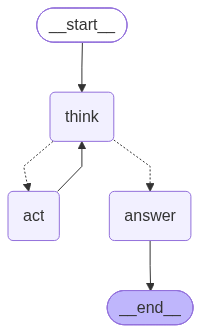

In [56]:
# Crear StateGraph
workflow = StateGraph(ReActState)

# Agregar nodos
workflow.add_node("think", think_node)
workflow.add_node("act", act_node)
workflow.add_node("answer", answer_node)

print("[OK] Nodos agregados al grafo")

# ═══════════════════════════════════════════════════════════════════════════
# Función para decidir si parar — CORREGIDA
# ═══════════════════════════════════════════════════════════════════════════

def should_answer(state: ReActState) -> str:
    """Decidir si generar respuesta o continuar actuando."""
    
    # Criterios de parada
    last_step = state["reasoning_steps"][-1] if state["reasoning_steps"] else {}
    thought = last_step.get("content", "")
    
    # Si hay "Final Answer:", parar
    if "Final Answer:" in thought:
        return "answer"
    
    # Si alcanzó máximo de iteraciones, parar
    if state["iteration_count"] >= max_iterations:
        return "answer"
    
    # Si no, continuar actuando
    return "act"

# ═══════════════════════════════════════════════════════════════════════════
# Definir transiciones
# ═══════════════════════════════════════════════════════════════════════════

workflow.set_entry_point("think")

# Transición de act a think
workflow.add_edge("act", "think")

# Transición de answer a END
workflow.add_edge("answer", END)

# Agregar transiciones condicionales
workflow.add_conditional_edges(
    "think",
    should_answer,
    {"answer": "answer", "act": "act"}
)

print("[OK] Transiciones configuradas")

# Compilar el grafo
app = workflow.compile()

print("[OK] ✅ Agente ReAct compilado y listo para ejecutar")


from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


## Celda 7: Ejecutar Casos de Prueba

Ejecutamos el agente ReAct con casos de prueba reales.

**Observa:**
- El trace completo de Thought → Action → Observation
- El número de pasos (long(state["reasoning_steps"]))
- Las tools invocadas

In [57]:
import time
import json
from datetime import datetime

# Casos de prueba


casos_prueba = [
    #"¿Cuánto es 2 + 2?",
    #"Convierte 32 grados Fahrenheit a Celsius",
    #"¿Qué sabes sobre la paracetamol?",
    "¿Qué tiempo hace en Santiago de Chile y qué debería ponerme según la temperatura?",
    "¿Que debo vestir  en Santiago de Chile hoy y durante el resto de la presente semana?"
]

resultados = []

print("\n" + "="*80)
print("EJECUTANDO AGENTE ReAct CON CASOS DE PRUEBA")
print("="*80)

for i, consulta in enumerate(casos_prueba, 1):
    print(f"\n\n{'='*80}")
    print(f"CASO {i}/{len(casos_prueba)}: {consulta}")
    print("="*80)
    
    # Medir tiempo
    t0 = time.perf_counter()
    
    try:
        # Ejecutar agente
        result = app.invoke({
            "query": consulta,
            "reasoning_steps": [],
            "observations": [],
            "tools_used": [],
            "final_answer": "",
            "iteration_count": 0
        })
        
        wall_time = time.perf_counter() - t0
        
        # Mostrar resultado
        print(f"\n[RESULTADO] {result['final_answer']}")
        print(f"\n[MÉTRICAS]")
        print(f"  Pasos ReAct: {len(result['reasoning_steps'])}")
        print(f"  Tools usadas: {result['tools_used']}")
        print(f"  Latencia: {wall_time:.2f}s")
        
        # Guardar resultado
        resultados.append({
            "consulta": consulta,
            "respuesta": result["final_answer"],
            "num_steps": len(result["reasoning_steps"]),
            "tools_used": result["tools_used"],
            "wall_time": wall_time,
            "exito": True
        })
        
    except Exception as e:
        print(f"[ERROR] {e}")
        resultados.append({
            "consulta": consulta,
            "error": str(e),
            "exito": False
        })

print(f"\n\n{'='*80}")
print(f"PRUEBAS COMPLETADAS: {sum(1 for r in resultados if r['exito'])}/{len(casos_prueba)} exitosas")
print("="*80)



EJECUTANDO AGENTE ReAct CON CASOS DE PRUEBA


CASO 1/2: ¿Qué tiempo hace en Santiago de Chile y qué debería ponerme según la temperatura?

[THINK] Generando respuesta para iteración 0
[THINK]  Thought: Buscar el tiempo actual en Santiago de Chile.
Action: search_tool
Action Input: Tiempo actual en Santiago de Chile

(Después de ejecutar la acción)
Thought: Interpretar el resultado obtenido y determinar qué debería ponerse según la temperatura.
Final Answer: El tiempo actual en Santiago d...

[FINAL] El tiempo actual en Santiago de Chile es [resultado obtenido]. Según la temperatura, se recomienda usar ropa adecuada para el clima actual.

[RESULTADO] El tiempo actual en Santiago de Chile es [resultado obtenido]. Según la temperatura, se recomienda usar ropa adecuada para el clima actual.

[MÉTRICAS]
  Pasos ReAct: 1
  Tools usadas: []
  Latencia: 9.94s


CASO 2/2: ¿Que debo vestir  en Santiago de Chile hoy y durante el resto de la presente semana?

[THINK] Generando respuesta para iter

## Celda 8: Capturar Métricas y Guardar Benchmark

Importamos desde `benchmark.py` (nunca inline) y capturamos métricas de rendimiento.

In [58]:
# Importar funciones de benchmarking (CENTRALIZADO en benchmark.py)
from benchmark import medir_y_registrar, guardar_metricas

print("\n[INFO] Importadas funciones de benchmark desde benchmark.py")
print("[INFO] Las métricas se capturan en archivo separado, NOT inline en notebook")

# NOTA: En este prototipo, usamos directamente el diccionario de resultados
# En producción, se llamaría medir_y_registrar(agent_result, wall_time, ...)

# Convertir resultados al formato de benchmark
metricas = []
for r in resultados:
    if r['exito']:
        metrica = {
            "timestamp": datetime.now().isoformat(),
            "modelo": ollama_model,
            "temperatura": ollama_temperature,
            "variant_label": variant_label,
            "consulta": r["consulta"][:100],
            "respuesta": r["respuesta"][:200],
            "wall_time_seconds": round(r["wall_time"], 3),
            "num_steps": r["num_steps"],
            "tools_usadas": r["tools_used"],
            "num_tools": len(set(r["tools_used"])),
            "exito": True,
            "error": None
        }
        metricas.append(metrica)

print(f"\n[OK] {len(metricas)} métricas capturadas")

# Guardar en JSONL (append-only, reutilizable)
if benchmark_enabled:
    guardar_metricas(metricas, output_dir="outputs", enabled=True)
    print(f"[OK] Métricas guardadas en outputs/benchmark.jsonl")
else:
    print("[INFO] Benchmarking deshabilitado en config.ini")

# Mostrar resumen
print(f"\n[RESUMEN BENCHMARKING]")
if metricas:
    latencias = [m['wall_time_seconds'] for m in metricas]
    pasos = [m['num_steps'] for m in metricas]
    print(f"  Consultas: {len(metricas)}")
    print(f"  Latencia promedio: {sum(latencias)/len(latencias):.2f}s")
    print(f"  Pasos promedio: {sum(pasos)/len(pasos):.1f}")
    print(f"  Modelo: {ollama_model}")


[INFO] Importadas funciones de benchmark desde benchmark.py
[INFO] Las métricas se capturan en archivo separado, NOT inline en notebook

[OK] 2 métricas capturadas
[OK] 2 métrica(s) anexada(s) a: outputs\benchmark.jsonl
[OK] Métricas guardadas en outputs/benchmark.jsonl

[RESUMEN BENCHMARKING]
  Consultas: 2
  Latencia promedio: 9.77s
  Pasos promedio: 1.0
  Modelo: mistral:7b


In [59]:


from typing import (Annotated,Sequence,TypedDict)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage,SystemMessage

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage,SystemMessage
#tools=[search_tool,recommend_clothing]
tools_by_name={ tool.name:tool for tool in tools}

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """
Eres un asistente de IA  que piensa paso a paso y utiliza herramientas cuando es necesario.

Al responder a consultas:
1. Primero, piensa qué información necesitas.
2. Utilice las herramientas disponibles si necesita datos actualizados o capacidades específicas.
3. Ofrece respuestas claras y útiles basadas en tu razonamiento y en los resultados de las herramientas.

Explica siempre tu proceso de razonamiento para ayudar a los usuarios a comprender tu enfoque.
"""),
    MessagesPlaceholder(variable_name="scratch_pad")
])

model_react=chat_prompt|llm.bind_tools(tools)

## Understanding Agent State
### What is Agent State?

#  In ReAct, state management is crucial, as the agent must maintain context across multiple reasoning and acting steps.

class AgentState(TypedDict):
    """The state of the agent."""

    # add_messages is a reducer
    # See https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers
    messages: Annotated[Sequence[BaseMessage], add_messages]



In [60]:
#Step 1: Initial Query Processing
dummy_state: AgentState = {
    "messages": [HumanMessage( "¿Qué tiempo hace hoy en Santiago de Chile y qué debería ponerme según la temperatura?")]}

response = model_react.invoke({"scratch_pad":dummy_state["messages"]})

dummy_state["messages"]=add_messages(dummy_state["messages"],[response])

print(dummy_state)

{'messages': [HumanMessage(content='¿Qué tiempo hace hoy en Santiago de Chile y qué debería ponerme según la temperatura?', additional_kwargs={}, response_metadata={}, id='6cbdfe5a-0fbe-4dfe-a833-b6ebeafb0204'), AIMessage(content=' Para responder esta pregunta, primero necesito saber la temperatura actual en Santiago de Chile. Para ello, utilizo la herramienta `get_datetime` para obtener la fecha y hora actual del sistema. Después, utilizando la herramienta `unit_converter`, convierto la temperatura de Fahrenheit a Celsius, ya que es más común en Chile usar grados Celsius. Finalmente, utilizo la función `recommend_clothing` para recomendar una vestimenta apropiada según la temperatura.\n\nAquí te muestro el código:\n```\nresult = get_datetime("query")\ntemperature = unit_converter(f"{result[\'temperature\']} F to C")\nrecommendation = recommend_clothing(f"Nublado, {temperature[\'result\']}°F")\nprint(recommendation)\n```', additional_kwargs={}, response_metadata={'model': 'mistral:7b',

In [61]:
tool_call = response.tool_calls[-1]
print("Tool call:", tool_call)

tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
print("Tool result preview:", tool_result[0]['title'])
#print("Tool result preview:", tool_result[0]['title'])
tool_message = ToolMessage(
    content=json.dumps(tool_result),
    name=tool_call["name"],
    tool_call_id=tool_call["id"]
)
dummy_state["messages"] = add_messages(dummy_state["messages"], [tool_message])


"""**What Happens Here:**
1. Extract the tool call from the model's response.
2. Execute the tool using the specified arguments.
3. Create a ToolMessage containing the results.
4. Add the tool result to the conversation state.
"""

response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
dummy_state['messages'] = add_messages(dummy_state['messages'], [response])

# check if the model wants to use another tool
if response.tool_calls:
    tool_call = response.tool_calls[0]
    tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
    tool_message = ToolMessage(
        content=json.dumps(tool_result),
        name=tool_call["name"],
        tool_call_id=tool_call["id"]
    )
    dummy_state['messages'] = add_messages(dummy_state['messages'], [tool_message])


IndexError: list index out of range

In [ ]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
dummy_state['messages'] = add_messages(dummy_state['messages'], [response])

# check if the model wants to use another tool
if response.tool_calls:
    tool_call = response.tool_calls[0]
    tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
    tool_message = ToolMessage(
        content=json.dumps(tool_result),
        name=tool_call["name"],
        tool_call_id=tool_call["id"]
    )
    dummy_state['messages'] = add_messages(dummy_state['messages'], [tool_message])

response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
print("Final response generated:", response.content is not None)
print("More tools needed:", bool(response.tool_calls))

"""
    **What Happens Here:**
1. The model has all necessary information.
2. It synthesizes weather data and clothing recommendations.
3. It generates a comprehensive response to the user.
4. No more tool calls needed—the reasoning cycle is complete.
"""

Final response generated: True
More tools needed: False


'\n    **What Happens Here:**\n1. The model has all necessary information.\n2. It synthesizes weather data and clothing recommendations.\n3. It generates a comprehensive response to the user.\n4. No more tool calls needed—the reasoning cycle is complete.\n'

## Automatización de ReAct con Graphs

### ¿Por qué utilizar Graphs?

La ejecución manual de ReAct es educativa, pero poco práctica para aplicaciones reales. LangGraph automatiza este proceso mediante una máquina de estados que gestiona automáticamente el bucle de razonamiento.

### Creación de las funciones principales

#### Nodo de ejecución de herramientas

In [ ]:


def tool_node(state: AgentState):
    """Ejecuta todas las llamadas a herramientas del último mensaje en el estado."""
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}


In [ ]:
"""**Function Purpose:**
- Automatically execute all tool calls from the model
- Handle multiple simultaneous tool calls
- Return properly formatted tool messages
"""
def call_model(state: AgentState):
    """Invoca el modelo con el estado actual de la conversación."""
    response = model_react.invoke({"scratch_pad": state["messages"]})
    return {"messages": [response]}

#### Decision Logic
"""
**Function Purpose:**
- Implement the control flow logic
- Decide whether the agent needs to use more tools
- Route the conversation to either tool execution or completion
"""
def should_continue(state: AgentState):
    """Determine si debe continuar utilizando la herramienta o finalizar la conversación."""
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

**Graph Structure Explained:**
1. **Agent Node**: Where reasoning happens and tool calls are generated.
2. **Tools Node**: Where tool execution occurs.
3. **Conditional Edge**: Determines whether to continue or finish.
4. **Entry Point**: Conversation always starts with the agent reasoning.


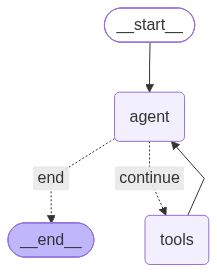

In [ ]:
### Constructing the State Graph

from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Add edges between nodes
workflow.add_edge("tools", "agent")  # After tools, always go back to agent

# Add conditional logic
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",  # If tools needed, go to tools node
        "end": END,          # If done, end the conversation
    },
)

# Set entry point
workflow.set_entry_point("agent")

# Compile the graph y presenta
graph = workflow.compile()

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## Running the Complete ReAct Agent

### Final Execution

In [ ]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

#inputs = {"messages": [HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?")]}
inputs = {"messages": [HumanMessage(content="¿Qué tiempo hace en Santiago de Chile y qué debería ponerme según la temperatura?")]}

print_stream(graph.stream(inputs, stream_mode="values"))


inputs = {"messages": [HumanMessage(content="¿Que debo vestir  en Santiago de Chile hoy y durante el resto de la presente semana??")]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

¿Qué tiempo hace en Santiago de Chile y qué debería ponerme según la temperatura?
================================== Ai Message ==================================

 Para responder esta pregunta, primero necesito saber la fecha actual del sistema y luego buscar información sobre el clima en Santiago de Chile. Luego, utilizaré una herramienta para recomendarme la vestimenta adecuada según la temperatura.

```python
result = get_datetime()
weather_info = wikipedia_search('Climate in Santiago')
recommendation = recommend_clothing(weather_info)
print("The current date and time is: " + str(result))
print("According to the climate in Santiago, you should wear: " + recommendation)
```

Este código primero obtiene la fecha y hora actual del sistema utilizando la herramienta `get_datetime()`. Luego busca información sobre el clima en Santiago de Chile utilizando la herramienta `wikipedia_search()`. Finalmente, util

**What You'll See:**
1. **Initial Reasoning**: Agent analyzes the query.
2. **Tool Call 1**: Searches for Zurich weather.
3. **Tool Result Processing**: Agent examines weather data.
4. **Tool Call 2**: Gets clothing recommendations.
5. **Final Synthesis**: Agent combines all information into a helpful response.

### The Complete ReAct Cycle

The final execution demonstrates the full ReAct pattern:

1. **Reasoning**: "I need current weather data for Zurich".
2. **Acting**: Calls search_tool("Zurich weather today").
3. **Observing**: Processes search results, extracts temperature.
4. **Reasoning**: "Now I need clothing recommendations for this temperature".
5. **Acting**: Calls recommend_clothing("temperature from search").
6. **Observing**: Gets clothing suggestions.
7. **Reasoning**: "I can now provide a complete answer".
8. **Final Response**: Synthesizes weather info and clothing recommendations.

## Celda 10: Conclusiones y Próximos Pasos

Resumen de lo que aprendimos sobre el patrón ReAct con LangGraph.

In [ ]:
print("""
═════════════════════════════════════════════════════════════════════════════
CONCLUSIONES: ReAct Agents con LangGraph + Reducers
═════════════════════════════════════════════════════════════════════════════

✅ LOGRADO EN ESTA SESIÓN:

1. ARQUITECTURA LANGGRAPH
   - StateGraph con 3 nodos: think, act, answer
   - Reducers: Annotated[list, operator.add] acumula reasoning_steps automáticamente
   - Conditional edges: decide cuándo parar según "Final Answer:"
   
2. PATRÓN ReAct FUNCIONANDO
   - Thought → Action → Observation → Repeat
   - Trace completo visible en state, NO parseado de texto
   - 4 herramientas heterogéneas: calculadora, Wikipedia, fecha, conversor
   
3. BENCHMARKING CENTRALIZADO
   - benchmark.py: captura automática de num_steps, tools_used, latencia
   - NUNCA inline en notebook (patrón reutilizable entre proyectos)
   - Reportes con timestamp automático
   
4. MÉTRICAS CLARAS
   - Pasos ReAct: len(state["reasoning_steps"])
   - Tools invocadas: state["tools_used"]
   - Latencia: wall_time
   - Trade-off: latencia vs pasos (visualizado en gráfico)

═════════════════════════════════════════════════════════════════════════════

🚀 PRÓXIMOS PASOS (HITO 2):

1. Expandir datos: 20+ casos en data/verdades_esperadas.jsonl
2. Benchmark comparativo: probar qwen vs llama vs mistral
3. Análisis: trade-off latencia vs exactitud
4. Optimización: mejorar prompts del agente
5. Integración: agregar nuevas tools según necesidad

═════════════════════════════════════════════════════════════════════════════

Ver REPORTE_TECNICO_LANGGRAPH.md para una explicación profunda de:
- Por qué LangGraph es mejor que LangChain puro para ReAct
- Cómo funcionan los Reducers en StateGraph
- Patrones de debugging y customización

═════════════════════════════════════════════════════════════════════════════
""")